In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls '/content/drive/MyDrive/counterfactual_pitch_sequence_analysis/'
%cd "/content/drive/MyDrive/counterfactual_pitch_sequence_analysis/"

Mounted at /content/drive
data  dataset  models  program
/content/drive/MyDrive/counterfactual_pitch_sequence_analysis


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [ ]:
# Define helper functions
def fit_sequence_standardizer(X):
    X_flat = X.reshape(-1, X.shape[-1])
    non_padding_mask = ~(np.all(X_flat == 0, axis=1))

    X_valid = X_flat[non_padding_mask]

    mean = X_valid.mean(axis=0)
    std = X_valid.std(axis=0)
    std = np.where(std == 0, 1.0, std)

    return mean.astype(np.float32), std.astype(np.float32)


def transform_sequence_standardizer(X, mean, std):
    X_scaled = X.copy().astype(np.float32)

    flat = X_scaled.reshape(-1, X_scaled.shape[-1])
    non_padding_mask = ~(np.all(flat == 0, axis=1))

    flat[non_padding_mask] = (flat[non_padding_mask] - mean) / std

    return X_scaled

def fit_tabular_standardizer(C):
    mean = C.mean(axis=0)
    std = C.std(axis=0)
    std = np.where(std == 0, 1.0, std)

    return mean.astype(np.float32), std.astype(np.float32)


def transform_tabular_standardizer(C, mean, std):
    return ((C.astype(np.float32) - mean) / std).astype(np.float32)

# Define Transformer model
class PaddingMaskLayer(layers.Layer):
    def call(self, inputs):
        is_padding = tf.reduce_all(tf.equal(inputs, 0.0), axis=-1)
        valid_mask = tf.logical_not(is_padding)
        return valid_mask

class PositionalEmbedding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model
        self.pos_emb = layers.Embedding(
            input_dim=seq_len,
            output_dim=d_model)

    def call(self, x):
        positions = tf.range(start=0, limit=self.seq_len, delta=1)
        pos = self.pos_emb(positions)
        return x + pos

class TransformerEncoderBlock(layers.Layer):
    def __init__(
        self,
        d_model,
        num_heads,
        ff_dim,
        dropout_rate=0.2,
        **kwargs):
        super().__init__(**kwargs)

        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout_rate)

        self.dropout1 = layers.Dropout(dropout_rate)
        self.norm1 = layers.LayerNormalization()

        self.ffn = models.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(d_model)])

        self.dropout2 = layers.Dropout(dropout_rate)
        self.norm2 = layers.LayerNormalization()

    def call(self, inputs, training=False):
        x, valid_mask = inputs
        attn_mask = tf.cast(valid_mask[:, tf.newaxis, :], tf.bool)

        attn_output = self.attn(
            x, x,
            attention_mask=attn_mask,
            training=training)
        attn_output = self.dropout1(attn_output, training=training)

        x = self.norm1(x + attn_output)

        ffn_output = self.ffn(x, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)

        x = self.norm2(x + ffn_output)

        return x

class MaskedMeanPooling(layers.Layer):
    def call(self, inputs):
        x, valid_mask = inputs

        mask = tf.cast(valid_mask, tf.float32)
        mask = mask[:, :, tf.newaxis]

        x = x * mask

        sum_x = tf.reduce_sum(x, axis=1)
        count = tf.reduce_sum(mask, axis=1)

        return sum_x / tf.maximum(count, 1.0)

def build_transformer_classifier_with_context(
    pitch_input_shape,
    context_input_shape,
    d_model=128,
    num_heads=4,
    ff_dim=256,
    num_blocks=2,
    context_dense_units=32,
    dense_units=64,
    dropout_rate=0.2,
    learning_rate=1e-3):
    pitch_inputs = layers.Input(
        shape=pitch_input_shape,
        name="pitch_sequence")  # (6, 7)

    valid_mask = PaddingMaskLayer(name="padding_mask")(pitch_inputs)

    x = layers.Dense(d_model, name="pitch_projection")(pitch_inputs)

    x = PositionalEmbedding(
        seq_len=pitch_input_shape[0],
        d_model=d_model,
        name="positional_embedding")(x)

    for i in range(num_blocks):
        x = TransformerEncoderBlock(
            d_model=d_model,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout_rate=dropout_rate,
            name=f"transformer_encoder_block_{i+1}"
        )([x, valid_mask])

    pitch_repr = MaskedMeanPooling(name="masked_mean_pooling")([x, valid_mask])

    pitch_repr = layers.Dense(
        dense_units,
        activation="relu",
        name="pitch_repr_dense")(pitch_repr)

    pitch_repr = layers.Dropout(
        dropout_rate,
        name="pitch_repr_dropout")(pitch_repr)

    context_inputs = layers.Input(
        shape=context_input_shape,
        name="context_features")

    context_repr = layers.Dense(
        context_dense_units,
        activation="relu",
        name="context_repr_dense")(context_inputs)

    context_repr = layers.Dropout(
        dropout_rate,
        name="context_repr_dropout")(context_repr)

    merged = layers.Concatenate(name="pitch_context_concat")(
        [pitch_repr, context_repr])

    z = layers.Dense(
        dense_units,
        activation="relu",
        name="merged_dense")(merged)

    z = layers.Dropout(
        dropout_rate,
        name="merged_dropout")(z)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="hard_contact_probability")(z)

    model = models.Model(
        inputs=[pitch_inputs, context_inputs],
        outputs=outputs,
        name="transformer_binary_classifier_with_context_C")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")])

    return model

In [ ]:
# Load dataset
DATASET_PATH = Path("./dataset/last_pitch/dataset_last_pitch.npz")
META_TRAIN_PATH = Path("./dataset/last_pitch/meta_train_last_pitch.csv")
META_TEST_PATH = Path("./dataset/last_pitch/meta_test_last_pitch.csv")

data = np.load(DATASET_PATH, allow_pickle=True)

X_train = data["X_train"]
C_train = data["C_train"]
y_train = data["y_train"]

X_test = data["X_test"]
C_test = data["C_test"]
y_test = data["y_test"]

pitch_feature_columns = data["pitch_feature_columns"] if "pitch_feature_columns" in data else None
c_feature_columns = data["c_feature_columns"] if "c_feature_columns" in data else None

meta_train = pd.read_csv(META_TRAIN_PATH)
meta_test = pd.read_csv(META_TEST_PATH)

# 0: Swing out, 1: in-play
CONTACT_THRESHOLD = 0.0
y_train_cls = (y_train > CONTACT_THRESHOLD).astype(np.float32)
y_test_cls = (y_test > CONTACT_THRESHOLD).astype(np.float32)

# tran: validation = 9: 1
VAL_SIZE = 0.1
RANDOM_STATE = 0
X_tr, X_val, C_tr, C_val, y_tr, y_val = train_test_split(
    X_train,C_train,
    y_train_cls,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True, stratify=y_train_cls)

x_mean, x_std = fit_sequence_standardizer(X_tr)
X_tr_scaled = transform_sequence_standardizer(X_tr, x_mean, x_std)
X_val_scaled = transform_sequence_standardizer(X_val, x_mean, x_std)
X_test_scaled = transform_sequence_standardizer(X_test, x_mean, x_std)

c_mean, c_std = fit_tabular_standardizer(C_tr)
C_tr_scaled = transform_tabular_standardizer(C_tr, c_mean, c_std)
C_val_scaled = transform_tabular_standardizer(C_val, c_mean, c_std)
C_test_scaled = transform_tabular_standardizer(C_test, c_mean, c_std)

In [ ]:
# Hyperparameter search
import gc
import time

# Fixed parameters
CONTEXT_DENSE_UNITS = 32
DROPOUT_RATE = 0.0
LEARNING_RATE = 1e-4
BATCH_SIZE = 512

SEARCH_EPOCHS = 200
SEARCH_PATIENCE = 10

EPOCHS = 200
PATIENCE = 10

HYPERPARAMETER_CANDIDATES = [
    {"d_model": 64,  "num_heads": 2, "ff_dim": 128,  "num_blocks": 1, "dense_units": 64},
    {"d_model": 64,  "num_heads": 4, "ff_dim": 128,  "num_blocks": 1, "dense_units": 64},
    {"d_model": 64,  "num_heads": 4, "ff_dim": 256,  "num_blocks": 2, "dense_units": 64},
    {"d_model": 128, "num_heads": 4, "ff_dim": 256,  "num_blocks": 2, "dense_units": 64},
    {"d_model": 128, "num_heads": 4, "ff_dim": 512,  "num_blocks": 2, "dense_units": 64},
    {"d_model": 256, "num_heads": 4, "ff_dim": 512,  "num_blocks": 2, "dense_units": 64},
    {"d_model": 256, "num_heads": 8, "ff_dim": 512,  "num_blocks": 2, "dense_units": 64},
    {"d_model": 256, "num_heads": 8, "ff_dim": 1024, "num_blocks": 2, "dense_units": 128}]

# Running hyperparameter search
search_results = []
for trial_id, params in enumerate(HYPERPARAMETER_CANDIDATES, start=1):
    print("=" * 80)
    print(f"Trial {trial_id}/{len(HYPERPARAMETER_CANDIDATES)}")
    print(params)

    tf.keras.backend.clear_session()
    gc.collect()

    trial_model = build_transformer_classifier_with_context(
        pitch_input_shape=X_tr_scaled.shape[1:],
        context_input_shape=C_tr_scaled.shape[1:],
        d_model=params["d_model"],
        num_heads=params["num_heads"],
        ff_dim=params["ff_dim"],
        num_blocks=params["num_blocks"],
        context_dense_units=CONTEXT_DENSE_UNITS,
        dense_units=params["dense_units"],
        dropout_rate=DROPOUT_RATE,
        learning_rate=LEARNING_RATE)

    early_stop_cb = callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=SEARCH_PATIENCE,
        restore_best_weights=True)

    start_time = time.time()

    trial_history = trial_model.fit(
        {"pitch_sequence": X_tr_scaled,
         "context_features": C_tr_scaled},
        y_tr,
        validation_data=(
            {"pitch_sequence": X_val_scaled,
             "context_features": C_val_scaled},
            y_val),
        epochs=SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop_cb],
        verbose=0)

    elapsed_sec = time.time() - start_time

    hist = trial_history.history
    val_auc_list = hist["val_auc"]
    best_epoch_idx = int(np.argmax(val_auc_list))
    best_epoch = best_epoch_idx + 1

    result = {
        "trial_id": trial_id,
        **params,
        "context_dense_units": CONTEXT_DENSE_UNITS,
        "dropout_rate": DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "best_epoch": best_epoch,
        "trained_epochs": len(val_auc_list),
        "best_val_auc": float(hist["val_auc"][best_epoch_idx]),
        "best_val_loss": float(hist["val_loss"][best_epoch_idx]),
        "best_val_accuracy": float(hist["val_accuracy"][best_epoch_idx]),
        "best_val_precision": float(hist["val_precision"][best_epoch_idx]),
        "best_val_recall": float(hist["val_recall"][best_epoch_idx]),
        "elapsed_sec": elapsed_sec}
    search_results.append(result)

    print(
        f"best_epoch={best_epoch}, "
        f"best_val_auc={result['best_val_auc']:.5f}, "
        f"val_loss={result['best_val_loss']:.5f}, "
        f"trained_epochs={result['trained_epochs']}, "
        f"elapsed_sec={elapsed_sec:.1f}")

    del trial_model
    gc.collect()

results_df = pd.DataFrame(search_results)

results_df = results_df.sort_values(
    ["best_val_auc", "best_val_loss"],
    ascending=[False, True]).reset_index(drop=True)

SAVE_DIR = Path("./models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

results_path = SAVE_DIR / "hyperparameter_search_results.csv"
results_df.to_csv(results_path, index=False)

print("\n===== Hyperparameter Search Results =====")
display(results_df)

best_result = results_df.iloc[0]

print("\n===== Best Hyperparameters =====")
print(best_result)

D_MODEL = int(best_result["d_model"])
NUM_HEADS = int(best_result["num_heads"])
FF_DIM = int(best_result["ff_dim"])
NUM_BLOCKS = int(best_result["num_blocks"])
DENSE_UNITS = int(best_result["dense_units"])

print("\nUse these hyperparameters for final training:")
print({
    "D_MODEL": D_MODEL,
    "NUM_HEADS": NUM_HEADS,
    "FF_DIM": FF_DIM,
    "NUM_BLOCKS": NUM_BLOCKS,
    "CONTEXT_DENSE_UNITS": CONTEXT_DENSE_UNITS,
    "DENSE_UNITS": DENSE_UNITS,
    "DROPOUT_RATE": DROPOUT_RATE,
    "LEARNING_RATE": LEARNING_RATE,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "PATIENCE": PATIENCE,
})

Trial 1/8
{'d_model': 64, 'num_heads': 2, 'ff_dim': 128, 'num_blocks': 1, 'dense_units': 64}
best_epoch=65, best_val_auc=0.80241, val_loss=0.52188, trained_epochs=75, elapsed_sec=97.7
Trial 2/8
{'d_model': 64, 'num_heads': 4, 'ff_dim': 128, 'num_blocks': 1, 'dense_units': 64}
best_epoch=58, best_val_auc=0.80126, val_loss=0.52152, trained_epochs=68, elapsed_sec=72.6
Trial 3/8
{'d_model': 64, 'num_heads': 4, 'ff_dim': 256, 'num_blocks': 2, 'dense_units': 64}
best_epoch=48, best_val_auc=0.80744, val_loss=0.51679, trained_epochs=58, elapsed_sec=76.9
Trial 4/8
{'d_model': 128, 'num_heads': 4, 'ff_dim': 256, 'num_blocks': 2, 'dense_units': 64}
best_epoch=28, best_val_auc=0.80464, val_loss=0.51946, trained_epochs=38, elapsed_sec=79.3
Trial 5/8
{'d_model': 128, 'num_heads': 4, 'ff_dim': 512, 'num_blocks': 2, 'dense_units': 64}
best_epoch=25, best_val_auc=0.80583, val_loss=0.51804, trained_epochs=35, elapsed_sec=90.6
Trial 6/8
{'d_model': 256, 'num_heads': 4, 'ff_dim': 512, 'num_blocks': 2, 'de

,trial_id,d_model,num_heads,ff_dim,num_blocks,dense_units,context_dense_units,dropout_rate,learning_rate,batch_size,best_epoch,trained_epochs,best_val_auc,best_val_loss,best_val_accuracy,best_val_precision,best_val_recall,elapsed_sec
0,6,256,4,512,2,64,32,0.0,0.0001,512,19,29,0.808438,0.521104,0.746407,0.773717,0.803878,143.522479
1,8,256,8,1024,2,128,32,0.0,0.0001,512,13,23,0.807441,0.515889,0.749733,0.746704,0.869319,149.586796
2,3,64,4,256,2,64,32,0.0,0.0001,512,48,58,0.807439,0.516786,0.750208,0.760234,0.840234,76.916049
3,7,256,8,512,2,64,32,0.0,0.0001,512,20,30,0.806445,0.517815,0.748189,0.751466,0.854373,139.893886
4,5,128,4,512,2,64,32,0.0,0.0001,512,25,35,0.805830,0.518040,0.746763,0.754560,0.843870,90.559039
5,4,128,4,256,2,64,32,0.0,0.0001,512,28,38,0.804644,0.519463,0.744863,0.751661,0.845486,79.319573
6,1,64,2,128,1,64,32,0.0,0.0001,512,65,75,0.802412,0.521881,0.744388,0.755897,0.834983,97.739605
7,2,64,4,128,1,64,32,0.0,0.0001,512,58,68,0.801258,0.521525,0.738092,0.743699,0.846294,72.648578



===== Best Hyperparameters =====
trial_id                 6.000000
d_model                256.000000
num_heads                4.000000
ff_dim                 512.000000
num_blocks               2.000000
dense_units             64.000000
context_dense_units     32.000000
dropout_rate             0.000000
learning_rate            0.000100
batch_size             512.000000
best_epoch              19.000000
trained_epochs          29.000000
best_val_auc             0.808438
best_val_loss            0.521104
best_val_accuracy        0.746407
best_val_precision       0.773717
best_val_recall          0.803878
elapsed_sec            143.522479
Name: 0, dtype: float64

Use these hyperparameters for final training:
{'D_MODEL': 256, 'NUM_HEADS': 4, 'FF_DIM': 512, 'NUM_BLOCKS': 2, 'CONTEXT_DENSE_UNITS': 32, 'DENSE_UNITS': 64, 'DROPOUT_RATE': 0.0, 'LEARNING_RATE': 0.0001, 'BATCH_SIZE': 512, 'EPOCHS': 200, 'PATIENCE': 10}


In [ ]:
# Train the Transformer model using the results of the hyperparameter search
model = build_transformer_classifier_with_context(
    pitch_input_shape=X_tr_scaled.shape[1:],
    context_input_shape=C_tr_scaled.shape[1:],
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_blocks=NUM_BLOCKS,
    context_dense_units=CONTEXT_DENSE_UNITS,
    dense_units=DENSE_UNITS,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE
)

model.summary()

early_stop_cb = callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=PATIENCE,
    restore_best_weights=True)

history = model.fit(
    {"pitch_sequence": X_tr_scaled,
     "context_features": C_tr_scaled},
    y_tr,
    validation_data=(
        {"pitch_sequence": X_val_scaled,
         "context_features": C_val_scaled},
        y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_cb],
    verbose=1
)

Model: "transformer_binary_classifier_with_context_C"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pitch_sequence      │ (None, 6, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch_projection    │ (None, 6, 256)    │      2,048 │ pitch_sequence[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 6, 256)    │      1,536 │ pitch_projection… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 6)         │          0 │ pitch_sequence[0… │
│ (PaddingMaskLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 6, 256)    │    527,104 │ positional_embed… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 6, 256)    │    527,104 │ transformer_enco… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_mean_pooling │ (None, 256)       │          0 │ transformer_enco… │
│ (MaskedMeanPooling) │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_features    │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch_repr_dense    │ (None, 64)        │     16,448 │ masked_mean_pool… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_repr_dense  │ (None, 32)        │        512 │ context_features… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch_repr_dropout  │ (None, 64)        │          0 │ pitch_repr_dense… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_repr_dropo… │ (None, 32)        │          0 │ context_repr_den… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch_context_conc… │ (None, 96)        │          0 │ pitch_repr_dropo… │
│ (Concatenate)       │                   │            │ context_repr_dro… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merged_dense        │ (None, 64)        │      6,208 │ pitch_context_co… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merged_dropout      │ (None, 64)        │          0 │ merged_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hard_contact_proba… │ (None, 1)         │         65 │ merged_dropout[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,081,025 (4.12 MB)

 Trainable params: 1,081,025 (4.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
148/148 ━━━━━━━━━━━━━━━━━━━━ 32s 115ms/step - accuracy: 0.6197 - auc: 0.6246 - loss: 0.6523 - precision: 0.6270 - recall: 0.8721 - val_accuracy: 0.6547 - val_auc: 0.6846 - val_loss: 0.6272 - val_precision: 0.6933 - val_recall: 0.7405
Epoch 2/200
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7219 - auc: 0.7691 - loss: 0.5555 - precision: 0.7264 - recall: 0.8457 - val_accuracy: 0.7362 - val_auc: 0.7894 - val_loss: 0.5337 - val_precision: 0.7367 - val_recall: 0.8582
Epoch 3/200
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7405 - auc: 0.7954 - loss: 0.5277 - precision: 0.7410 - recall: 0.8589 - val_accuracy: 0.7395 - val_auc: 0.7965 - val_loss: 0.5264 - val_precision: 0.7477 - val_recall: 0.8408
Epoch 4/200
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7425 - auc: 0.8003 - loss: 0.5225 - precision: 0.7431 - recall: 0.8591 - val_accuracy: 0.7384 - val_auc: 0.7990 - val_loss: 0.5254 - val_precision: 0.7515 - val_recall: 0.8295
Epoch 5/200
148/148 ━━

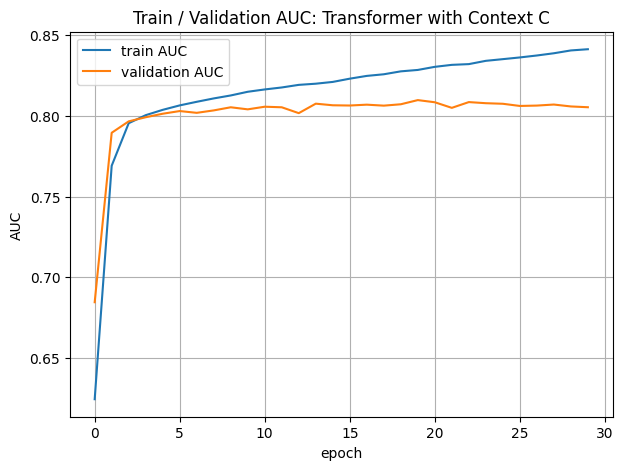

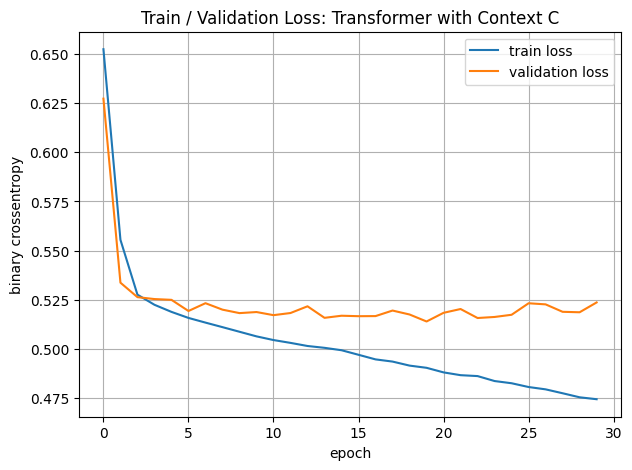

33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step


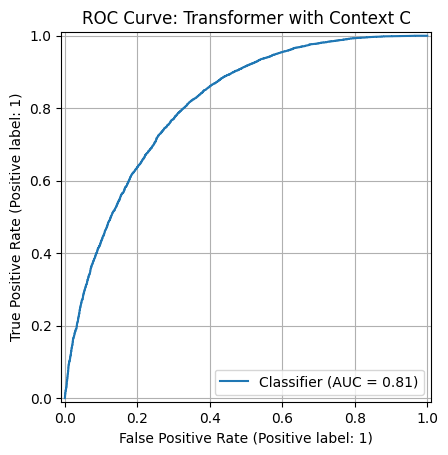

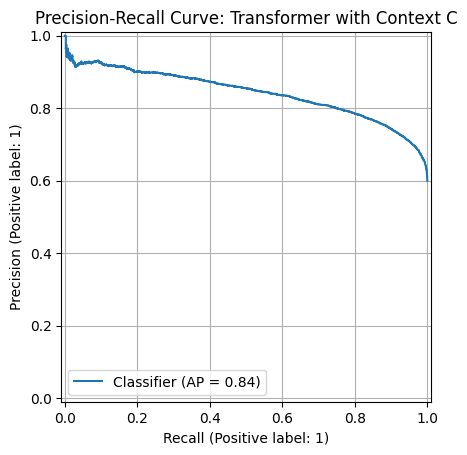

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step

===== Threshold Search on Validation =====
best threshold: 0.43
best validation F1: 0.8064041221935959


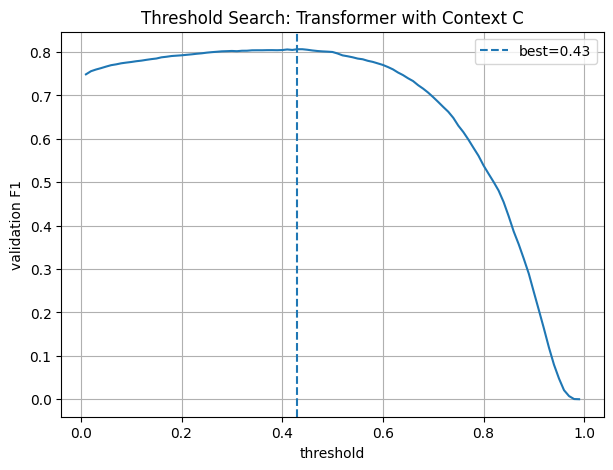


===== Test Result with Best Threshold =====
threshold: 0.43
Accuracy : 0.7561108752350336
Precision: 0.7545793905720982
Recall   : 0.8792231438397734
F1       : 0.8121466946975006
ROC AUC  : 0.8111040777758431

Confusion matrix
[[3774 2827]
 [1194 8692]]

Classification report
              precision    recall  f1-score   support

         0.0       0.76      0.57      0.65      6601
         1.0       0.75      0.88      0.81      9886

    accuracy                           0.76     16487
   macro avg       0.76      0.73      0.73     16487
weighted avg       0.76      0.76      0.75     16487

Save training & testing results


In [ ]:
# plot learning curve
plt.figure(figsize=(7, 5))
plt.plot(history.history["auc"], label="train AUC")
plt.plot(history.history["val_auc"], label="validation AUC")
plt.xlabel("epoch")
plt.ylabel("AUC")
plt.title("Train / Validation AUC: Transformer with Context C")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("epoch")
plt.ylabel("binary crossentropy")
plt.title("Train / Validation Loss: Transformer with Context C")
plt.grid(True)
plt.legend()
plt.show()

# ROC・PR curve
y_test_prob = model.predict(
    {"pitch_sequence": X_test_scaled,
     "context_features": C_test_scaled},
    batch_size=BATCH_SIZE
).ravel()

# Default threshold = 0.5
y_test_pred = (y_test_prob >= 0.5).astype(int)

RocCurveDisplay.from_predictions(y_test_cls, y_test_prob)
plt.title("ROC Curve: Transformer with Context C")
plt.grid(True)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test_cls, y_test_prob)
plt.title("Precision-Recall Curve: Transformer with Context C")
plt.grid(True)
plt.show()

# Find the threshold that maximizes the F1 score on the validation set
y_val_prob = model.predict(
    {"pitch_sequence": X_val_scaled,
     "context_features": C_val_scaled,},
    batch_size=BATCH_SIZE).ravel()

thresholds = np.linspace(0.01, 0.99, 99)
f1_scores = []

for th in thresholds:
    y_val_pred = (y_val_prob >= th).astype(int)
    f1_scores.append(f1_score(y_val, y_val_pred, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("\n===== Threshold Search on Validation =====")
print("best threshold:", best_threshold)
print("best validation F1:", f1_scores[best_idx])

plt.figure(figsize=(7, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, linestyle="--", label=f"best={best_threshold:.2f}")
plt.xlabel("threshold")
plt.ylabel("validation F1")
plt.title("Threshold Search: Transformer with Context C")
plt.grid(True)
plt.legend()
plt.show()

y_test_pred_best = (y_test_prob >= best_threshold).astype(int)

print("\n===== Test Result with Best Threshold =====")
print("threshold:", best_threshold)
print("Accuracy :", accuracy_score(y_test_cls, y_test_pred_best))
print("Precision:", precision_score(y_test_cls, y_test_pred_best, zero_division=0))
print("Recall   :", recall_score(y_test_cls, y_test_pred_best, zero_division=0))
print("F1       :", f1_score(y_test_cls, y_test_pred_best, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test_cls, y_test_prob))

print("\nConfusion matrix")
print(confusion_matrix(y_test_cls, y_test_pred_best))

print("\nClassification report")
print(classification_report(y_test_cls, y_test_pred_best, zero_division=0))

# save the results
meta_test_pred = meta_test.copy()
meta_test_pred["y_true_reg"] = y_test
meta_test_pred["y_true_cls"] = y_test_cls.astype(int)
meta_test_pred["pred_prob"] = y_test_prob
meta_test_pred["pred_cls_05"] = y_test_pred
meta_test_pred["pred_cls_best"] = y_test_pred_best
meta_test_pred["best_threshold"] = best_threshold

SAVE_DIR = Path("./models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

model.save(SAVE_DIR / "transformer.keras")

np.savez(
    SAVE_DIR / "transformer_train_info.npz",
    x_mean=x_mean,
    x_std=x_std,
    c_mean=c_mean,
    c_std=c_std,
    best_threshold=best_threshold,
    contact_threshold=CONTACT_THRESHOLD,
    pitch_feature_columns=pitch_feature_columns,
    c_feature_columns=c_feature_columns)

meta_test_pred.to_csv(
    SAVE_DIR / "transformer_test_meta_info.csv",
    index=False)

print("Save training & testing results")

In [ ]:
from google.colab import runtime
runtime.unassign()